In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [177]:
titles = pd.read_csv("dataset/netflix_titles.csv")
users = pd.read_csv("dataset/Netflix Userbase.csv")
churn = pd.read_csv("dataset/netflix_large_user_data.csv")


In [178]:
titles.head()

,Show ID,Type,Title,Director,Cast,Country,Date_added,Release_year,Rating,Duration,Listed_in,Description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [179]:
titles.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Show ID       8807 non-null   str  
 1   Type          8807 non-null   str  
 2   Title         8807 non-null   str  
 3   Director      6173 non-null   str  
 4   Cast          7982 non-null   str  
 5   Country       7976 non-null   str  
 6   Date_added    8797 non-null   str  
 7   Release_year  8807 non-null   int64
 8   Rating        8803 non-null   str  
 9   Duration      8804 non-null   str  
 10  Listed_in     8807 non-null   str  
 11  Description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [180]:
titles.describe()

,Release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [181]:
titles.drop_duplicates(inplace=True)
titles.isnull().sum()

Show ID            0
Type               0
Title              0
Director        2634
Cast             825
Country          831
Date_added        10
Release_year       0
Rating             4
Duration           3
Listed_in          0
Description        0
dtype: int64

In [182]:
titles= titles.fillna({'Director':'Unknown', 'Cast':'Unknown', 'Country':'Unknown','Rating':'0'})
titles=titles.dropna(subset=['Duration','Date_added'])

In [183]:
titles.rename(columns={'Show_ID': 'Show_ID'}, inplace=True)

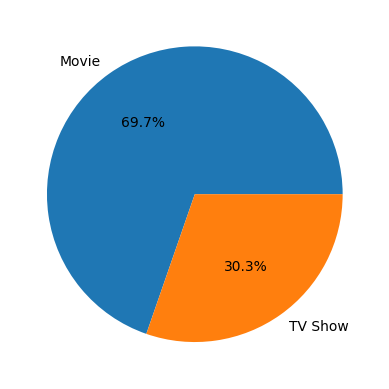

In [184]:
titles["Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

In [185]:
titles["Listed_in"].value_counts().head(10)

Listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            219
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

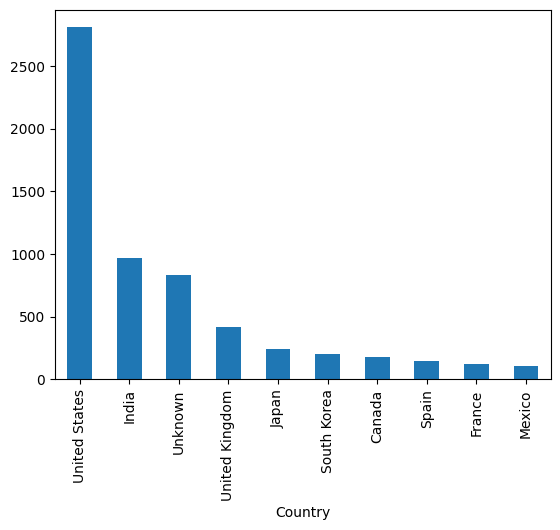

In [186]:
titles["Country"].value_counts().head(10).plot(kind="bar")

plt.show()

In [187]:
users.head()

,User_ID,Subscription_Type,Monthly_Revenue,Join_Date,Last_Payment Date,Country,Age,Gender,Device,Plan_Duration
0,1,Basic,10,15-01-2022,10-06-2023,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-2021,22-06-2023,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-2023,27-06-2023,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-2022,26-06-2023,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-2023,28-06-2023,Germany,33,Male,Smartphone,1 Month


In [188]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   User_ID            2500 non-null   int64
 1   Subscription_Type  2500 non-null   str  
 2   Monthly_Revenue    2500 non-null   int64
 3   Join_Date          2500 non-null   str  
 4   Last_Payment Date  2500 non-null   str  
 5   Country            2500 non-null   str  
 6   Age                2500 non-null   int64
 7   Gender             2500 non-null   str  
 8   Device             2500 non-null   str  
 9   Plan_Duration      2500 non-null   str  
dtypes: int64(3), str(7)
memory usage: 327.0 KB


In [189]:
users.describe()

,User_ID,Monthly_Revenue,Age
count,2500.00000,2500.000000,2500.000000
mean,1250.50000,12.508400,38.795600
std,721.83216,1.686851,7.171778
min,1.00000,10.000000,26.000000
25%,625.75000,11.000000,32.000000
50%,1250.50000,12.000000,39.000000
75%,1875.25000,14.000000,45.000000
max,2500.00000,15.000000,51.000000


In [190]:
users.rename(columns={'Last_Payment Date':'Last_Payment_Date'},inplace=True)

In [191]:
users.drop_duplicates(inplace=True)
users.isnull().sum()

User_ID              0
Subscription_Type    0
Monthly_Revenue      0
Join_Date            0
Last_Payment_Date    0
Country              0
Age                  0
Gender               0
Device               0
Plan_Duration        0
dtype: int64

In [192]:
total_revenue=users['Monthly_Revenue'].sum()
print(total_revenue)

31271


In [193]:
revenue_Plan=users.groupby("Subscription_Type")["Monthly_Revenue"].sum()
print(revenue_Plan)

Subscription_Type
Basic       12469
Premium      9229
Standard     9573
Name: Monthly_Revenue, dtype: int64


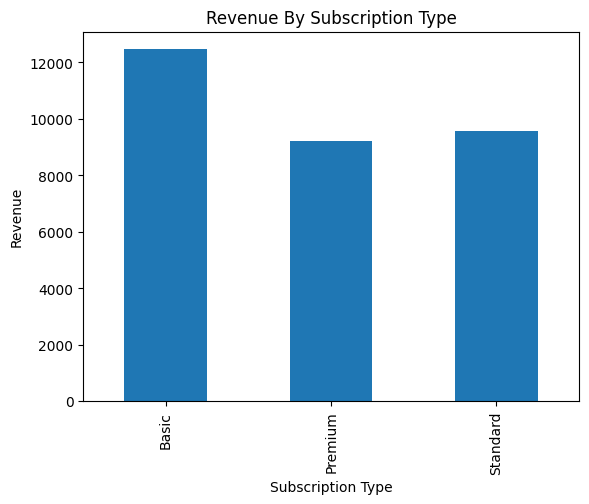

In [194]:
revenue_Plan.plot(kind="bar")
plt.title("Revenue By Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Revenue")

plt.show()

In [195]:
device=users["Device"].value_counts()
print(device)

Device
Laptop        636
Tablet        633
Smartphone    621
Smart TV      610
Name: count, dtype: int64


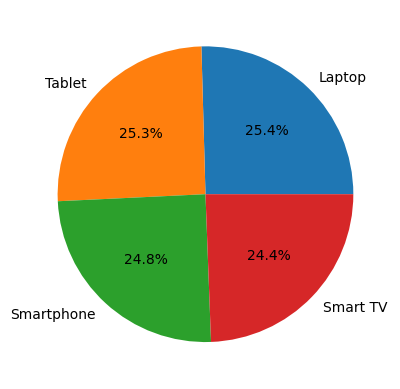

In [196]:
device.plot(kind="pie",autopct="%1.1f%%")
plt.ylabel("")
plt.show()

In [197]:
bins=[0,18,25,35,45,55,100]
labels=[
    "0-18",
    "19-25",
    "26-35",
    "36-45",
    "46-55",
    "55+"]
users["Age_Group"]=pd.cut(users["Age"],bins=bins,labels=labels,include_lowest=True)
print(users[['Age','Age_Group']].head())

   Age Age_Group
0   28     26-35
1   35     26-35
2   42     36-45
3   51     46-55
4   33     26-35


In [198]:
churn.head()

,Customer ID,Subscription Length (Months),Customer Satisfaction Score (1-10),Daily Watch Time (Hours),Engagement Rate (1-10),Device Used Most Often,Genre Preference,Region,Payment History (On-Time/Delayed),Subscription Plan,Churn Status (Yes/No),Support Queries Logged,Age,Monthly Income ($),Promotional Offers Used,Number of Profiles Created
0,C00001,12,10,4.85,4,Tablet,Action,Europe,On-Time,Basic,No,10,33,6250,5,2
1,C00002,12,8,1.75,9,Laptop,Thriller,Europe,On-Time,Basic,Yes,9,28,7018,1,5
2,C00003,3,4,2.75,9,Smart TV,Comedy,Asia,On-Time,Premium,Yes,3,18,1055,1,5
3,C00004,3,7,3.00,9,Smart TV,Drama,Europe,Delayed,Premium,No,5,32,6707,5,4
4,C00005,24,2,1.37,5,Mobile,Drama,North America,On-Time,Standard,Yes,2,59,1506,3,5


In [199]:
churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Customer ID                         1000 non-null   str    
 1   Subscription Length (Months)        1000 non-null   int64  
 2   Customer Satisfaction Score (1-10)  1000 non-null   int64  
 3   Daily Watch Time (Hours)            1000 non-null   float64
 4   Engagement Rate (1-10)              1000 non-null   int64  
 5   Device Used Most Often              1000 non-null   str    
 6   Genre Preference                    1000 non-null   str    
 7   Region                              1000 non-null   str    
 8   Payment History (On-Time/Delayed)   1000 non-null   str    
 9   Subscription Plan                   1000 non-null   str    
 10  Churn Status (Yes/No)               1000 non-null   str    
 11  Support Queries Logged              1000 non-null   int

In [200]:
churn.describe()

,Subscription Length (Months),Customer Satisfaction Score (1-10),Daily Watch Time (Hours),Engagement Rate (1-10),Support Queries Logged,Age,Monthly Income ($),Promotional Offers Used,Number of Profiles Created
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,9.17700,5.379000,2.829420,5.511000,4.951000,43.840000,5251.452000,2.422000,2.937000
std,8.21859,2.856487,1.302673,2.871607,3.111636,15.356439,2720.859072,1.689607,1.430062
min,1.00000,1.000000,0.500000,1.000000,0.000000,18.000000,510.000000,0.000000,1.000000
25%,3.00000,3.000000,1.650000,3.000000,2.000000,30.000000,3073.250000,1.000000,2.000000
50%,6.00000,5.000000,2.890000,6.000000,5.000000,44.000000,5286.000000,2.000000,3.000000
75%,12.00000,8.000000,3.932500,8.000000,8.000000,57.000000,7598.250000,4.000000,4.000000
max,24.00000,10.000000,5.000000,10.000000,10.000000,70.000000,9994.000000,5.000000,5.000000


In [201]:
churn.rename(columns={'Subscription Length (Months)':'Subscription Length'},inplace=True)
churn.rename(columns={'Customer Satisfaction Score (1-10)':'Customer Satisfaction Score'},inplace=True)
churn.rename(columns={'Daily Watch Time (Hours)':'Daily Watch Time'},inplace=True)
churn.rename(columns={'Engagement Rate (1-10)':'Engagement Rate'},inplace=True)
churn.rename(columns={'Payment History (On-Time/Delayed)':'Payment History'},inplace=True)
churn.rename(columns={'Churn Status (Yes/No)':'Churn Status'},inplace=True)
churn.rename(columns={'Monthly Income ($)':'Monthly Income'},inplace=True)


In [202]:
churn.columns=churn.columns.str.replace(" ","_")

In [203]:
churn.head()

,Customer_ID,Subscription_Length,Customer_Satisfaction_Score,Daily_Watch_Time,Engagement_Rate,Device_Used_Most_Often,Genre_Preference,Region,Payment_History,Subscription_Plan,Churn_Status,Support_Queries_Logged,Age,Monthly_Income,Promotional_Offers_Used,Number_of_Profiles_Created
0,C00001,12,10,4.85,4,Tablet,Action,Europe,On-Time,Basic,No,10,33,6250,5,2
1,C00002,12,8,1.75,9,Laptop,Thriller,Europe,On-Time,Basic,Yes,9,28,7018,1,5
2,C00003,3,4,2.75,9,Smart TV,Comedy,Asia,On-Time,Premium,Yes,3,18,1055,1,5
3,C00004,3,7,3.00,9,Smart TV,Drama,Europe,Delayed,Premium,No,5,32,6707,5,4
4,C00005,24,2,1.37,5,Mobile,Drama,North America,On-Time,Standard,Yes,2,59,1506,3,5


In [204]:
churn["Churn_Flag"]=churn["Churn_Status"].map({
    "Yes":1,
    "No":0
})
print(churn[["Churn_Status","Churn_Flag"]].head())

  Churn_Status  Churn_Flag
0           No           0
1          Yes           1
2          Yes           1
3           No           0
4          Yes           1


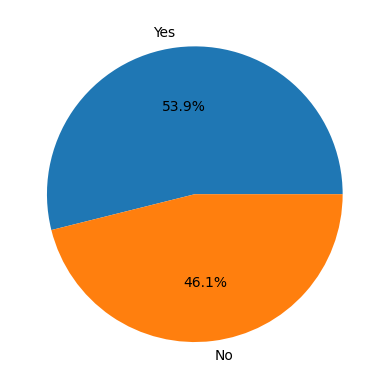

In [205]:
churn["Churn_Status"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.show()

In [206]:
#create connection with MySql database
from sqlalchemy import create_engine

username="root"
password="arnab123laha"
host="localhost"
port="3306"
database="netflix_db"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")
table_name ="netflix_titles"
titles.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data Successfully loaded into table '{table_name}' in database '{database}'. ")

Data Successfully loaded into table 'netflix_titles' in database 'netflix_db'. 
